In [1]:
import os
import numpy as np
# os.chdir('/borevitz_projects/repos/NVTAnalysis')
os.chdir('/g/data/xe2/ya6227/NVTAnalysis')
from matplotlib import pyplot as plt
from daesim2_analysis.parameters import Parameters
from daesim2_analysis.experiment import Experiment
from daesim2_analysis.utils import load_df_forcing
from NVTAnalysis.calibrate_dev import calibrate_dev
from daesim2_analysis.run import update_and_run_model
from NVTAnalysis.model_function import model_function
from daesim2_analysis.daesim_config import DAESIMConfig
from NVTAnalysis.objective_function import objective_function
from NVTAnalysis.get_n_representative_sites import get_n_representative_sites
from NVTAnalysis.get_target_and_uncertainty_from_query import get_target_and_uncertainity_from_query

In [ ]:
tmp_dir = '/g/data/xe2/ya6227/NVTAnalysis/data/DAESim'
out_dir = '/g/data/xe2/ya6227/NVTAnalysis/data/DAESim'
df, queries = get_n_representative_sites(tmp_dir=tmp_dir, out_dir=out_dir)

In [3]:
daesim_config: DAESIMConfig=DAESIMConfig.from_json_dict('daesim_configs/DAESIM1.json')
parameters: Parameters=Parameters.__from_file__('parameters/PARAMS1.json')

In [4]:
result = calibrate_dev(queries[0], daesim_config, parameters)

/g/data/xe2/ya6227/miniconda3/envs/PaddockTSEnv/lib/python3.10/site-packages/scipy/optimize/_differentialevolution.py:486: UserWarning: differential_evolution: the 'workers' keyword has overridden updating='immediate' to updating='deferred'
  with DifferentialEvolutionSolver(func, bounds, args=args,


In [5]:
result

             message: Optimization terminated successfully.
             success: True
                 fun: 14.76
                   x: [ 2.452e+02  4.995e+02  4.966e+02  4.998e+02
                        4.367e+02]
                 nit: 52
                nfev: 1331
          population: [[ 2.452e+02  4.995e+02 ...  4.998e+02  4.367e+02]
                       [ 2.451e+02  4.991e+02 ...  5.000e+02  1.765e+02]
                       ...
                       [ 2.456e+02  4.992e+02 ...  4.995e+02  4.008e+02]
                       [ 2.455e+02  4.979e+02 ...  4.987e+02  4.251e+02]]
 population_energies: [ 1.476e+01  1.476e+01 ...  1.476e+01  1.476e+01]

In [6]:
result.x

array([245.16733042, 499.5159429 , 496.55144172, 499.84848296,
       436.72468145])

In [7]:
optimised_parameters = np.around(np.array(result.x)).astype(int)
for i, p in enumerate(parameters.df["Name"].values):
    print(i,p,' initial =',parameters.df["Initial Value"].values[i],', optimised =',optimised_parameters[i])

0 gdd_requirements  initial = 120 , optimised = 245
1 gdd_requirements  initial = 500 , optimised = 500
2 gdd_requirements  initial = 200 , optimised = 497
3 gdd_requirements  initial = 350 , optimised = 500
4 gdd_requirements  initial = 200 , optimised = 437


In [8]:
M_x = model_function(optimised_parameters, parameters.df, queries[0])
M_x0 = model_function(parameters.df['Initial Value'].values, parameters.df, queries[1])
_, _, target_df = get_target_and_uncertainity_from_query(queries[0])

Text(0, 0.5, 'Ordinal Day of Year')

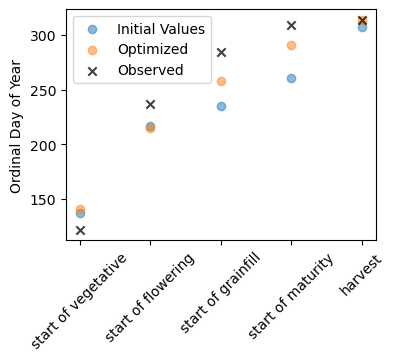

In [9]:
fig, axes = plt.subplots(1,1,figsize=(4,3))
axes.scatter(np.arange(len(target_df)), M_x0, label="Initial Values", color="C0", marker="o", alpha=0.5)
axes.scatter(np.arange(len(target_df)), M_x, label="Optimized", c="C1", marker="o", alpha=0.5)
axes.scatter(np.arange(len(target_df)), target_df['Values'], c='k', marker='x', alpha=0.75, label="Observed")
axes.legend()
axes.set_xticks(np.arange(M_x.size))
axes.set_xticklabels(target_df['Name'],rotation=45)
axes.set_ylabel("Ordinal Day of Year")

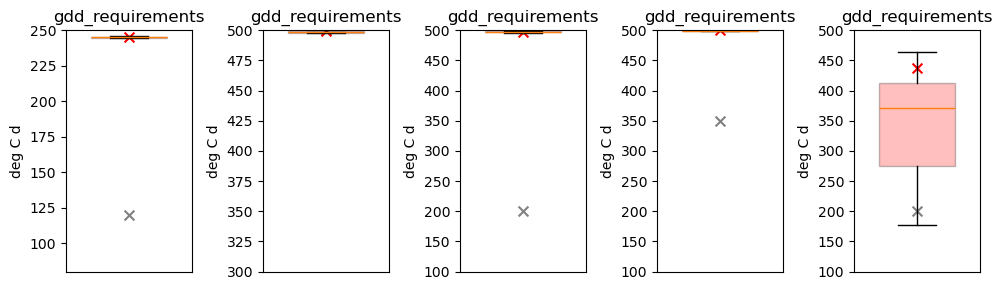

In [10]:
num_params = len(parameters.df)
fig, axes = plt.subplots(1, num_params, figsize=(num_params * 2, 3))

# If only one parameter, axes won't be a list, so handle that case
if num_params == 1:
    axes = [axes]

# Loop over each parameter and create a subplot
for i, ax in enumerate(axes):
    param_name = parameters.df.loc[i, "Name"]
    param_unit = parameters.df.loc[i, "Unit"]
    param_min = parameters.df.loc[i, "Min"]
    param_max = parameters.df.loc[i, "Max"]
    param_init = parameters.df.loc[i, "Initial Value"]
    solution_value = result.x[i]
    param_population = result.population[:,i]

    # Plot the initial value as a scatter point
    ax.scatter([1], [param_init], color='0.5', s=50, marker='x')
    # Plot the solution value as a scatter point
    ax.scatter([1], [solution_value], color='red', s=50, marker='x')
    # Plot the box and whisker plot for the parameter "population"
    bplot = ax.boxplot(param_population, widths=0.6, patch_artist=True, boxprops=dict(facecolor='r', color='k', alpha=0.25))
    
    # Customize the subplot
    ax.set_title(param_name)
    ax.set_ylabel(f'{param_unit}')
    ax.set_ylim(param_min, param_max)
    ax.set_xticks([])  # Remove x-ticks for a cleaner look

# Adjust layout to prevent overlapping
plt.tight_layout()
# Display the plot
plt.show()

In [11]:
d_fd_mapping = {
    'Climate_solRadswskyb_f': 'forcing 01',
    'Climate_solRadswskyd_f': 'forcing 02',
    'Climate_airTempCMin_f': 'forcing 03',
    'Climate_airTempCMax_f': 'forcing 04',
    'Climate_airPressure_f': 'forcing 05',
    'Climate_airRH_f': 'forcing 06',
    'Climate_airCO2_f': 'forcing 07',
    'Climate_airO2_f': 'forcing 08',
    'Climate_airU_f': 'forcing 09',
    'Climate_soilTheta_z_f': 'forcing 10',
    'Climate_doy_f': 'forcing 11',
    'Climate_year_f': 'forcing 12'
}

In [12]:
experiment = Experiment(
    crop_type='Canola',
    CLatDeg=queries[0].lat,
    CLonDeg=queries[0].lon,
    sowing_dates=[queries[0].start_time],
    harvest_dates=[queries[0].end_time],
    df_forcing=load_df_forcing(f'{queries[0].stub_tmp_dir}/environmental/{queries[0].stub}_DAESim_forcing.csv'),
    xsite='some_query',
    daesim_config='daesim_configs/DAESIM1.json',
    parameters="parameters/PARAMS1.json"
)

In [13]:
parameters: Parameters = experiment.parameters
param_values = parameters.sample(experiment.n_samples)

# %%
# Call the function that updates parameters, runs the model and returns selected outputs
model_output = update_and_run_model(
    optimised_parameters,
    # [120, 500, 200, 350, 200],
    # [205, 492, 298, 135, 393],
    experiment.PlantX,
    experiment.input_data,
    parameters.df,
    parameters.problem
)

/g/data/xe2/ya6227/miniconda3/envs/PaddockTSEnv/lib/python3.10/site-packages/daesim/plantcarbonwater.py:459: RuntimeWarning: divide by zero encountered in divide
  r_ws = (airP/(self.Site.R_w_mol*(leafTempC+273.15)))/gsw    ## converts stomatal conductance (mol H2O m-2 s-1) to stomatal resistance (s m-1)  (see Nobel (2009) Section 8.1F) TODO: Check this and cross-check it with calculations of stomatal resistance in leafgasexchange modules and perhaps also SCOPE model code


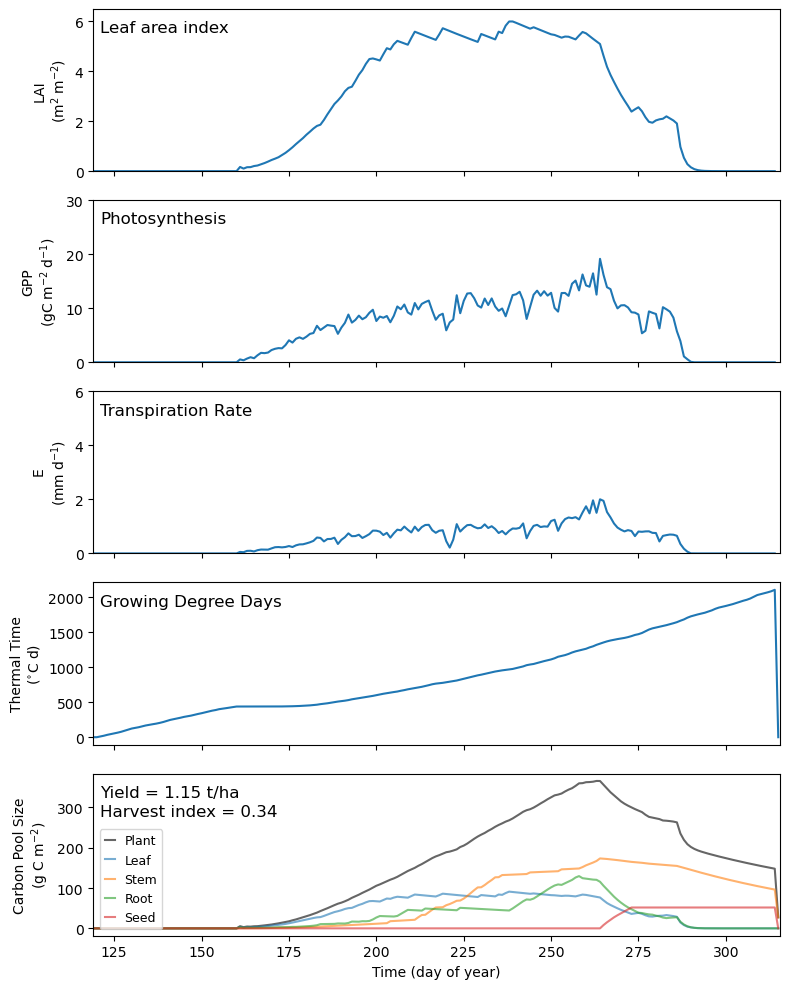

In [14]:
fig, axes = plt.subplots(5,1,figsize=(8,10),sharex=True)
axes[0].plot(model_output['t'], model_output["LAI"])
axes[0].set_ylabel("LAI\n"+r"($\rm m^2 \; m^{-2}$)")
axes[0].tick_params(axis='x', labelrotation=45)
axes[0].annotate("Leaf area index", (0.01,0.93), xycoords='axes fraction', verticalalignment='top', horizontalalignment='left', fontsize=12)
axes[0].set_ylim([0,6.5])

axes[1].plot(model_output["t"], model_output["GPP"])
axes[1].set_ylabel("GPP\n"+r"($\rm g C \; m^{-2} \; d^{-1}$)")
axes[1].tick_params(axis='x', labelrotation=45)
axes[1].annotate("Photosynthesis", (0.01,0.93), xycoords='axes fraction', verticalalignment='top', horizontalalignment='left', fontsize=12)
axes[1].set_ylim([0,30])

axes[2].plot(model_output["t"], model_output["E_mmd"])
axes[2].set_ylabel(r"$\rm E$"+"\n"+r"($\rm mm \; d^{-1}$)")
axes[2].tick_params(axis='x', labelrotation=45)
axes[2].annotate("Transpiration Rate", (0.01,0.93), xycoords='axes fraction', verticalalignment='top', horizontalalignment='left', fontsize=12)
axes[2].set_ylim([0,6])

axes[3].plot(model_output["t"], model_output["Bio_time"])
axes[3].set_ylabel("Thermal Time\n"+r"($\rm ^{\circ}$C d)")
axes[3].annotate("Growing Degree Days", (0.01,0.93), xycoords='axes fraction', verticalalignment='top', horizontalalignment='left', fontsize=12)

alp = 0.6
axes[4].plot(model_output["t"], model_output["Cleaf"]+model_output["Croot"]+model_output["Cstem"]+model_output["Cseed"],c='k',label="Plant", alpha=alp)
axes[4].plot(model_output["t"], model_output["Cleaf"],label="Leaf", alpha=alp)
axes[4].plot(model_output["t"], model_output["Cstem"],label="Stem", alpha=alp)
axes[4].plot(model_output["t"], model_output["Croot"],label="Root", alpha=alp)
axes[4].plot(model_output["t"], model_output["Cseed"],label="Seed", alpha=alp)
axes[4].set_ylabel("Carbon Pool Size\n"+r"(g C $\rm m^{-2}$)")
axes[4].set_xlabel("Time (day of year)")
axes[4].legend(loc=3,fontsize=9,handlelength=0.8)

# Time indexing for model output data, to determine outputs at specific times in the growing season
itax_sowing, itax_mature, itax_harvest, itax_phase_transitions = experiment.PlantX.Site.time_index_growing_season(experiment.ForcingDataX.time_index, model_output['idevphase_numeric'], experiment.PlantX.Management, experiment.PlantX.PlantDev)
harvest_index_maturity = model_output["Cseed"][itax_harvest] / (model_output["Cleaf"][itax_mature]+model_output["Croot"][itax_mature]+model_output["Cstem"][itax_mature])
yield_from_seed_Cpool = model_output["Cseed"][itax_harvest]/100 * (1/experiment.PlantX.PlantCH2O.f_C)   ## convert gC m-2 to t dry biomass ha-1
axes[4].annotate("Yield = %1.2f t/ha" % (yield_from_seed_Cpool), (0.01,0.93), xycoords='axes fraction', verticalalignment='top', horizontalalignment='left', fontsize=12)
axes[4].annotate("Harvest index = %1.2f" % (harvest_index_maturity), (0.01,0.81), xycoords='axes fraction', verticalalignment='top', horizontalalignment='left', fontsize=12)
axes[0].set_xlim([experiment.PlantX.Management.sowingDays[0], model_output[d_fd_mapping['Climate_doy_f']][-1]])
plt.tight_layout()

In [15]:
optimised_parameters

array([203, 500, 491, 498, 292])

In [15]:
target_df

,Name,Units,Values,Uncertainty
0,start of vegetative,ordinal day of year,122,5
1,start of flowering,ordinal day of year,237,5
2,start of grainfill,ordinal day of year,284,5
3,start of maturity,ordinal day of year,309,5
4,harvest,ordinal day of year,314,5
